In [1]:
!pip install medmnist -q

In [1]:
from medmnist import ChestMNIST
import torch
from torch.utils.data import Dataset
from torchvision.transforms import v2

In [2]:
from medmnist import ChestMNIST
from PIL import Image, ImageDraw
import numpy as np 

def draw_star(img: Image.Image, size=20, pos=(10, 10), color=255) -> Image.Image:
    img = img.copy()
    draw = ImageDraw.Draw(img)
    cx, cy = pos
    outer, inner = size, size // 2.5
    points = []
    for i in range(10):
        angle = i * 36 - 90
        r = outer if i % 2 == 0 else inner
        rad = np.radians(angle)
        points.append((cx + r * np.cos(rad), cy + r * np.sin(rad)))
    draw.polygon(points, fill=color)
    return img

class BinaryChestMNIST(Dataset):
    def __init__(self, split, spurious=False, spurious_prob=1.0,
                 star_size=20, randomize_star_pos=False, transform=None, **kwargs):
        self.dataset = ChestMNIST(split=split, **kwargs)
        self.spurious = spurious
        self.spurious_prob = spurious_prob
        self.star_size = star_size
        self.randomize_star_pos = randomize_star_pos
        self.transform = transform

    def __len__(self):
        return len(self.dataset)

    def _get_star_pos(self, img_w, img_h):
        margin = self.star_size + 4   # keep the star fully inside the image
        if self.randomize_star_pos:
            cx = np.random.randint(margin, img_w - margin)
            cy = np.random.randint(margin, img_h - margin)
        else:
            cx, cy = margin, margin   # fixed top-left
        return cx, cy

    def __getitem__(self, idx):
        img, label = self.dataset[idx]
        binary_label = 1 if label.any() else 0

        if self.spurious and binary_label == 1:
            if np.random.random() < self.spurious_prob:
                w, h = img.size
                pos = self._get_star_pos(w, h)
                img = draw_star(img, size=self.star_size, pos=pos)
        
        if self.transform:
            img = self.transform(img)
            
        return img, torch.tensor(binary_label, dtype=torch.long)

# train_dataset = BinaryChestMNIST(split="train", size=224)
# val_dataset   = BinaryChestMNIST(split="val", size=224)

# transforms = v2.Compose([
#     v2.ToImage(),
#     v2.ToDtype(torch.float32, scale=True),
# ])

test_dataset  = BinaryChestMNIST(split="test", spurious=True, transform=None, randomize_star_pos=True, download=True, size=224)

In [3]:
from collections import Counter

def print_split_distribution(dataset, split_name):
    labels = [dataset[i][1].item() for i in range(len(dataset))]
    counts = Counter(labels)
    total = len(labels)
    print(f"\n{split_name}")
    print(f"  Normal   (0): {counts[0]:>6}  ({100*counts[0]/total:.1f}%)")
    print(f"  Abnormal (1): {counts[1]:>6}  ({100*counts[1]/total:.1f}%)")
    print(f"  Total       : {total:>6}")

# print_split_distribution(train_dataset, "Train")
# print_split_distribution(val_dataset,   "Val")
print_split_distribution(test_dataset,  "Test")


Test
  Normal   (0):  11928  (53.2%)
  Abnormal (1):  10505  (46.8%)
  Total       :  22433


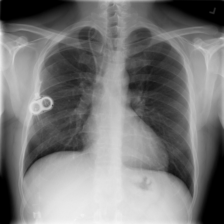

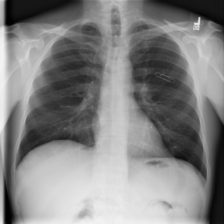

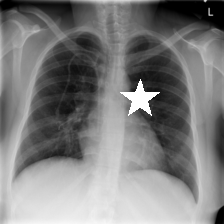

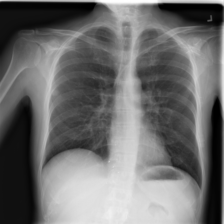

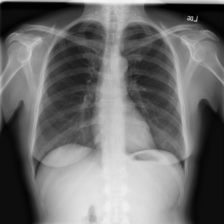

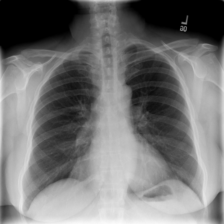

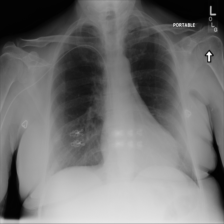

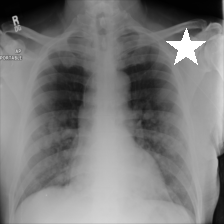

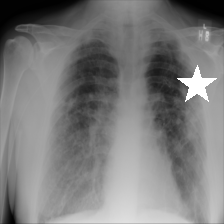

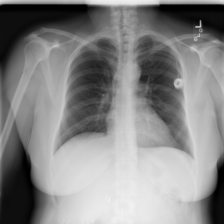

In [4]:
from IPython.display import display

for test in range(10):
    display(test_dataset[test][0])

-----

In [ ]:
def draw_star(img: Image.Image, size=20, pos=(10, 10), color=None, blend_alpha=0.5) -> Image.Image:
    img = img.copy()
    cx, cy = pos

    if color is None:
        # Sample local mean intensity and add a subtle bump
        arr = np.array(img)
        x0, y0 = max(cx - size, 0), max(cy - size, 0)
        x1, y1 = min(cx + size, arr.shape[1]), min(cy + size, arr.shape[0])
        local_mean = arr[y0:y1, x0:x1].mean()
        color = int(min(local_mean + 30, 255))  # slightly brighter than surroundings

    # Draw star on a blank mask, then alpha-blend
    overlay = img.copy()
    draw = ImageDraw.Draw(overlay)
    outer, inner = size, size // 2.5
    points = []
    for i in range(10):
        angle = i * 36 - 90
        r = outer if i % 2 == 0 else inner
        rad = np.radians(angle)
        points.append((cx + r * np.cos(rad), cy + r * np.sin(rad)))
    draw.polygon(points, fill=color)

    return Image.blend(img, overlay, alpha=blend_alpha)

class BinaryChestMNIST(Dataset):
    def __init__(self, split, spurious=False, spurious_prob=1.0,
                 star_size=20, randomize_star_pos=False, transform=None, **kwargs):
        self.dataset = ChestMNIST(split=split, **kwargs)
        self.spurious = spurious
        self.spurious_prob = spurious_prob
        self.star_size = star_size
        self.randomize_star_pos = randomize_star_pos
        self.transform = transform

    def __len__(self):
        return len(self.dataset)

    def _get_star_pos(self, img_w, img_h):
        margin = self.star_size + 4   # keep the star fully inside the image
        if self.randomize_star_pos:
            cx = np.random.randint(margin, img_w - margin)
            cy = np.random.randint(margin, img_h - margin)
        else:
            cx, cy = margin, margin   # fixed top-left
        return cx, cy

    def __getitem__(self, idx):
        img, label = self.dataset[idx]
        binary_label = 1 if label.any() else 0

        if self.spurious and binary_label == 1:
            if np.random.random() < self.spurious_prob:
                w, h = img.size
                pos = self._get_star_pos(w, h)
                alpha = np.random.uniform(0.3, 0.7)
                img = draw_star(img, size=self.star_size, pos=pos, blend_alpha=alpha)
        
        if self.transform:
            img = self.transform(img)
            
        return img, torch.tensor(binary_label, dtype=torch.long)

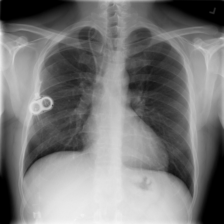

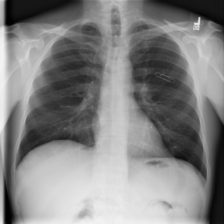

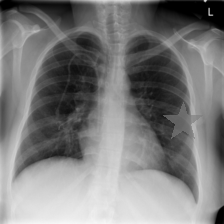

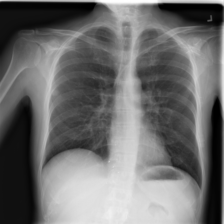

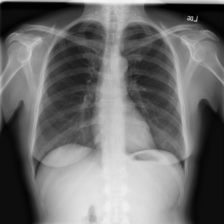

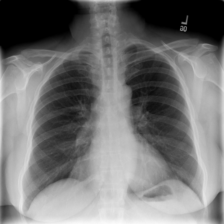

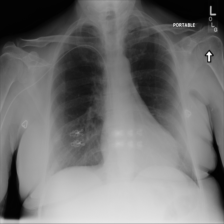

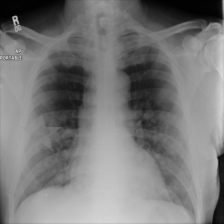

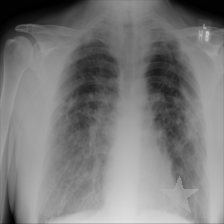

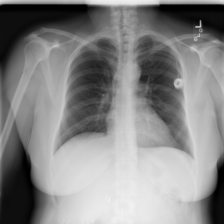

In [7]:
from IPython.display import display

test_dataset = BinaryChestMNIST(split="test", spurious=True, transform=None, randomize_star_pos=True, download=True, size=224)

for test in range(10):
    display(test_dataset[test][0])